In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

In [2]:
df = pd.read_csv("../data/online_shoppers_intention.csv")

print("\n--- Data Shape ---")
display(df.shape)

print("\n--- Data Information ---")
df.info()

print("\n--- Data Sample ---")
display(df.head())


--- Data Shape ---


(12330, 18)


--- Data Information ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12330 entries, 0 to 12329
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Administrative           12330 non-null  int64  
 1   Administrative_Duration  12330 non-null  float64
 2   Informational            12330 non-null  int64  
 3   Informational_Duration   12330 non-null  float64
 4   ProductRelated           12330 non-null  int64  
 5   ProductRelated_Duration  12330 non-null  float64
 6   BounceRates              12330 non-null  float64
 7   ExitRates                12330 non-null  float64
 8   PageValues               12330 non-null  float64
 9   SpecialDay               12330 non-null  float64
 10  Month                    12330 non-null  object 
 11  OperatingSystems         12330 non-null  int64  
 12  Browser                  12330 non-null  int64  
 13  Region                   12330 non-null  int64  
 

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,1,1,1,1,Returning_Visitor,False,False
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,Feb,2,2,1,2,Returning_Visitor,False,False
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,4,1,9,3,Returning_Visitor,False,False
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,Feb,3,2,2,4,Returning_Visitor,False,False
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,Feb,3,3,1,4,Returning_Visitor,True,False


In [3]:
# Null Investigation
null_counts = df.isnull().sum()
null_pct = (null_counts / len(df) * 100).round(2)
null_summary = pd.DataFrame({
    "null_count": null_counts,
    "null_pct": null_pct,
}).sort_values("null_count", ascending=False)

print(f"Total columns: {df.shape[1]} | Columns with nulls: {(null_counts > 0).sum()}")
display(null_summary[null_summary["null_count"] > 0])

# Bar chart of columns with missing values
cols_with_nulls = null_summary[null_summary["null_count"] > 0]
if not cols_with_nulls.empty:
    fig, ax = plt.subplots(figsize=(10, 4))
    bars = ax.bar(cols_with_nulls.index, cols_with_nulls["null_count"],
                  color=sns.color_palette("Set2", len(cols_with_nulls)))
    ax.set_title("Missing Values per Column")
    ax.set_ylabel("Null Count")
    ax.set_ylim(0, cols_with_nulls["null_count"].max() * 1.18)
    ax.tick_params(axis="x", labelrotation=30)
    for bar in bars:
        h = bar.get_height()
        ax.annotate(
            f"{h:,} ({h / len(df):.1%})",
            xy=(bar.get_x() + bar.get_width() / 2, h),
            xytext=(0, 4), textcoords="offset points",
            ha="center", va="bottom", fontsize=9,
        )
    plt.tight_layout()
    plt.show()
else:
    print("No missing values found.")

Total columns: 18 | Columns with nulls: 0


,null_count,null_pct


No missing values found.


In [4]:
# Cardinality of categorical / discrete columns
cat_cols = [
    "Month", "VisitorType", "Weekend",
    "OperatingSystems", "Browser", "Region", "TrafficType", "SpecialDay",
]

cardinality = pd.DataFrame({
    "dtype": df[cat_cols].dtypes.astype(str),
    "distinct_values": [df[c].nunique(dropna=False) for c in cat_cols],
    "values": [
        df[c].value_counts().index.tolist() if df[c].dtype == object
        else sorted(df[c].unique().tolist())
        for c in cat_cols
    ],
}, index=cat_cols)

display(cardinality)

,dtype,distinct_values,values
Month,object,10,"[May, Nov, Mar, Dec, Oct, Sep, Aug, Jul, June,..."
VisitorType,object,3,"[Returning_Visitor, New_Visitor, Other]"
Weekend,bool,2,"[False, True]"
OperatingSystems,int64,8,"[1, 2, 3, 4, 5, 6, 7, 8]"
Browser,int64,13,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13]"
Region,int64,9,"[1, 2, 3, 4, 5, 6, 7, 8, 9]"
TrafficType,int64,20,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14..."
SpecialDay,float64,6,"[0.0, 0.2, 0.4, 0.6, 0.8, 1.0]"


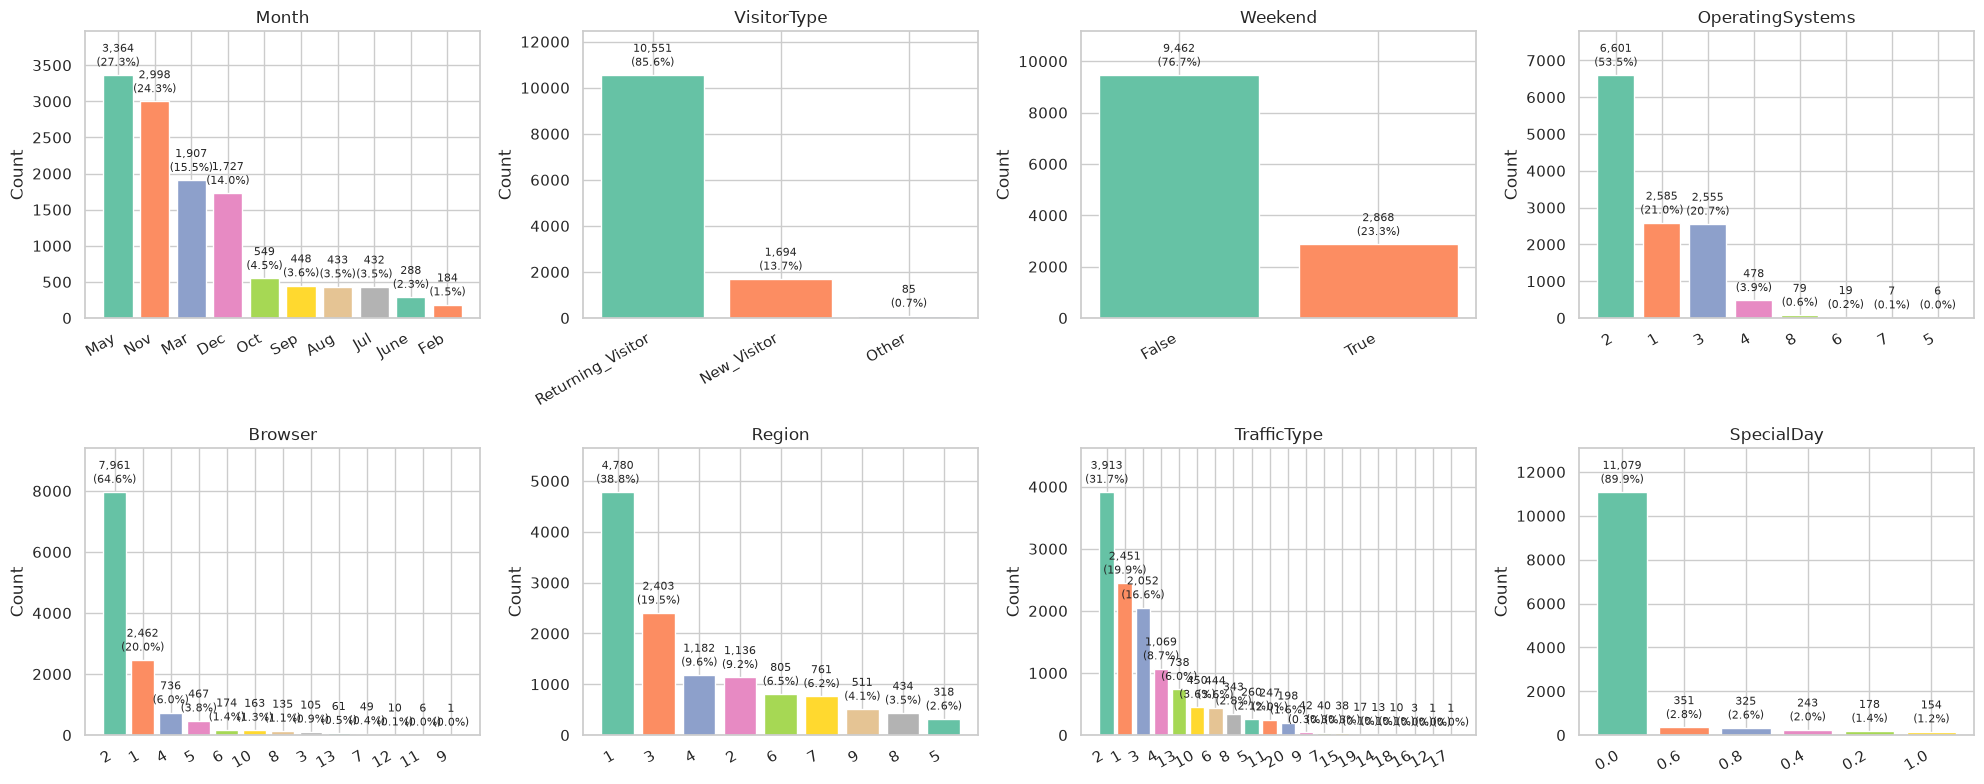

In [5]:
# Categorical / discrete feature distributions
n_cols = 4
n_rows = -(-len(cat_cols) // n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, n_rows * 4))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    counts = df[col].value_counts()
    total = counts.sum()
    bars = axes[i].bar(counts.index.astype(str), counts.values, color=sns.color_palette("Set2", len(counts)))
    axes[i].set_title(col)
    axes[i].set_ylabel("Count")
    axes[i].set_ylim(0, counts.max() * 1.18)
    plt.setp(axes[i].get_xticklabels(), rotation=30, ha="right")
    for bar in bars:
        height = bar.get_height()
        axes[i].annotate(
            f"{height:,}\n({height / total:.1%})",
            xy=(bar.get_x() + bar.get_width() / 2, height),
            xytext=(0, 4),
            textcoords="offset points",
            ha="center", va="bottom",
            fontsize=8,
        )

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues
count,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000
mean,2.315166,80.818611,0.503569,34.472398,31.731468,1194.746220,0.022191,0.043073,5.889258
std,3.321784,176.779107,1.270156,140.749294,44.475503,1913.669288,0.048488,0.048597,18.568437
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,7.000000,184.137500,0.000000,0.014286,0.000000
50%,1.000000,7.500000,0.000000,0.000000,18.000000,598.936905,0.003112,0.025156,0.000000
75%,4.000000,93.256250,0.000000,0.000000,38.000000,1464.157214,0.016813,0.050000,0.000000
max,27.000000,3398.750000,24.000000,2549.375000,705.000000,63973.522230,0.200000,0.200000,361.763742


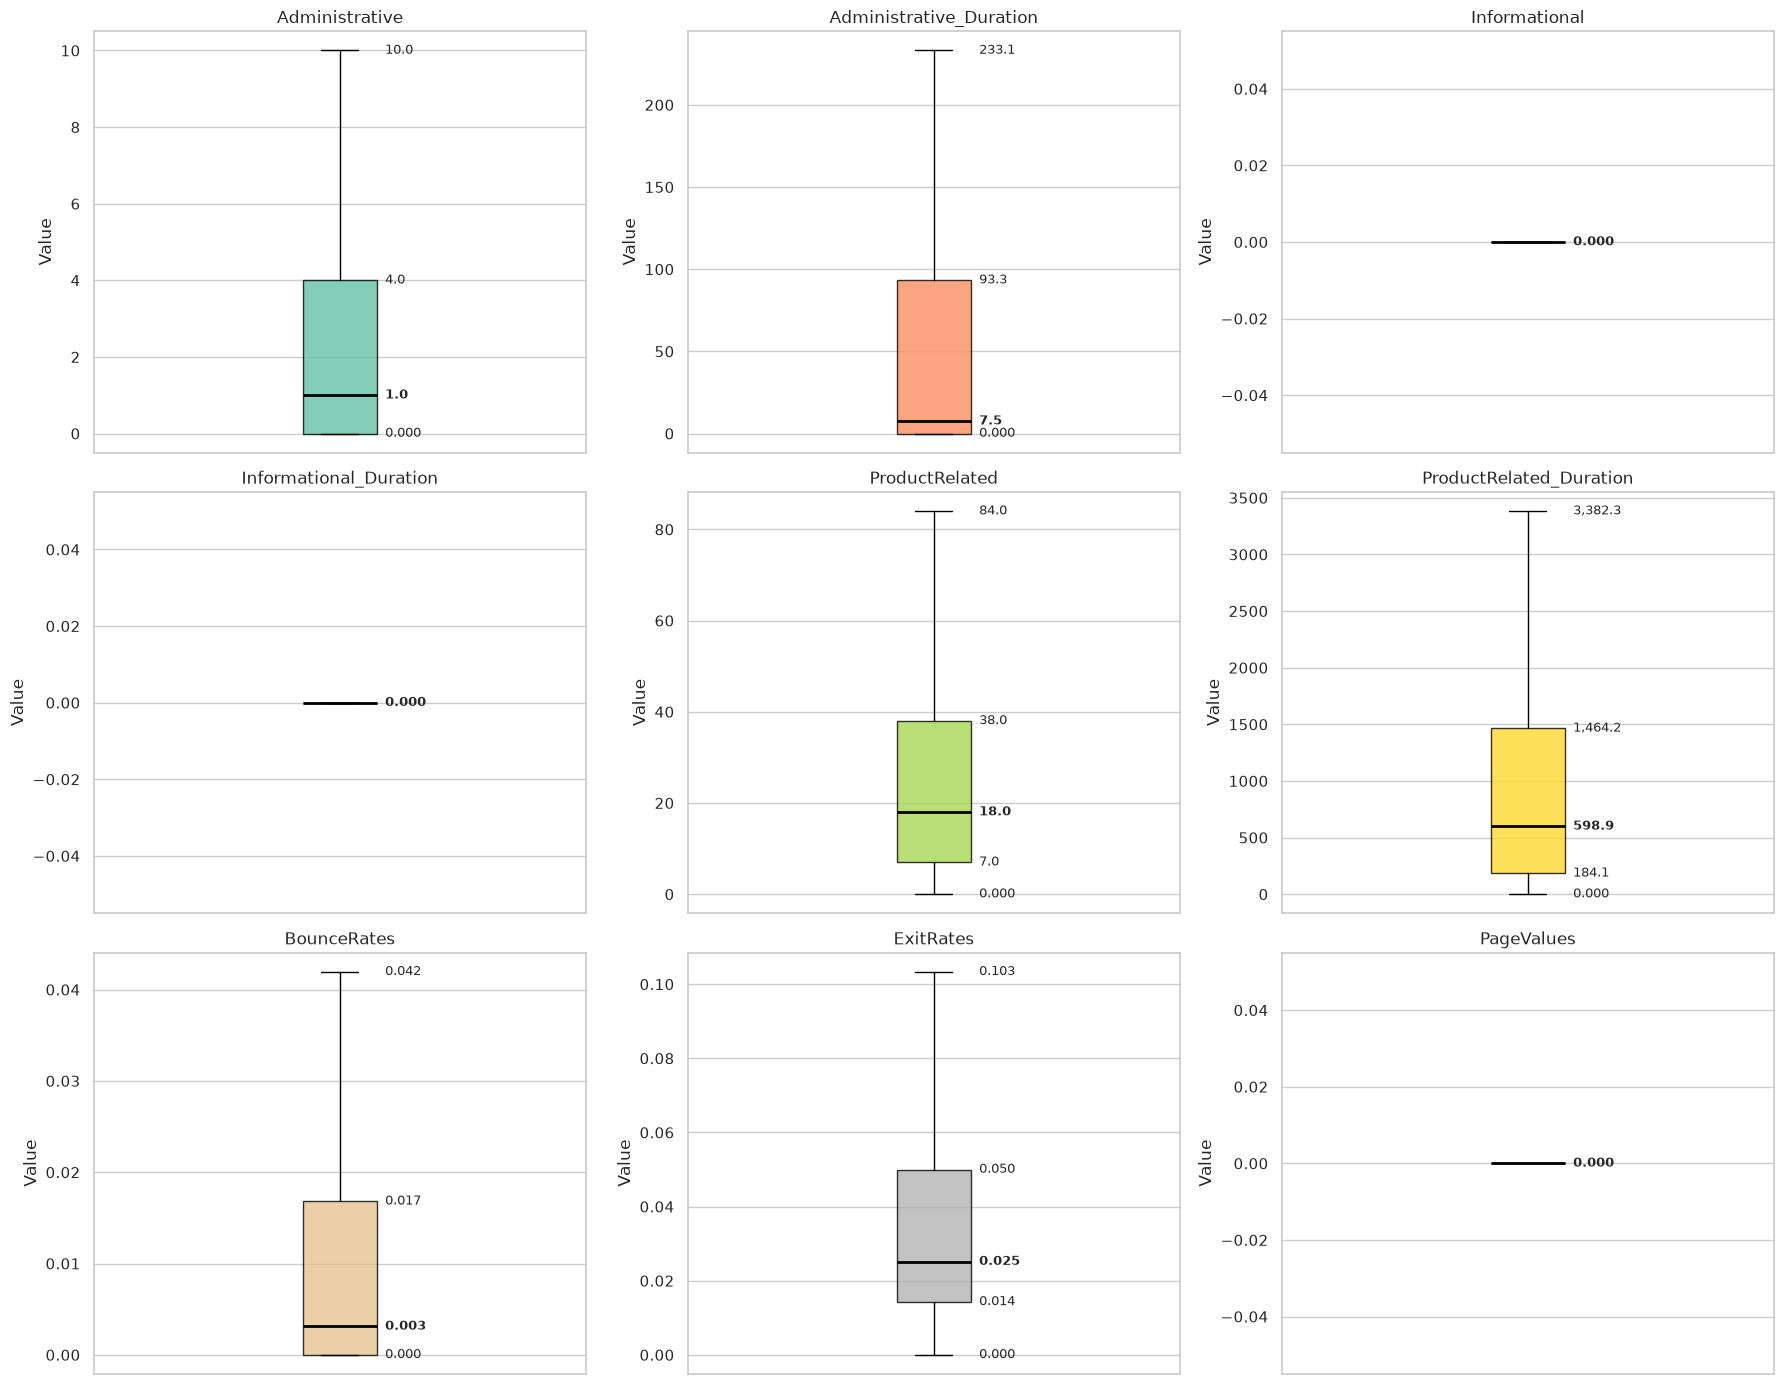

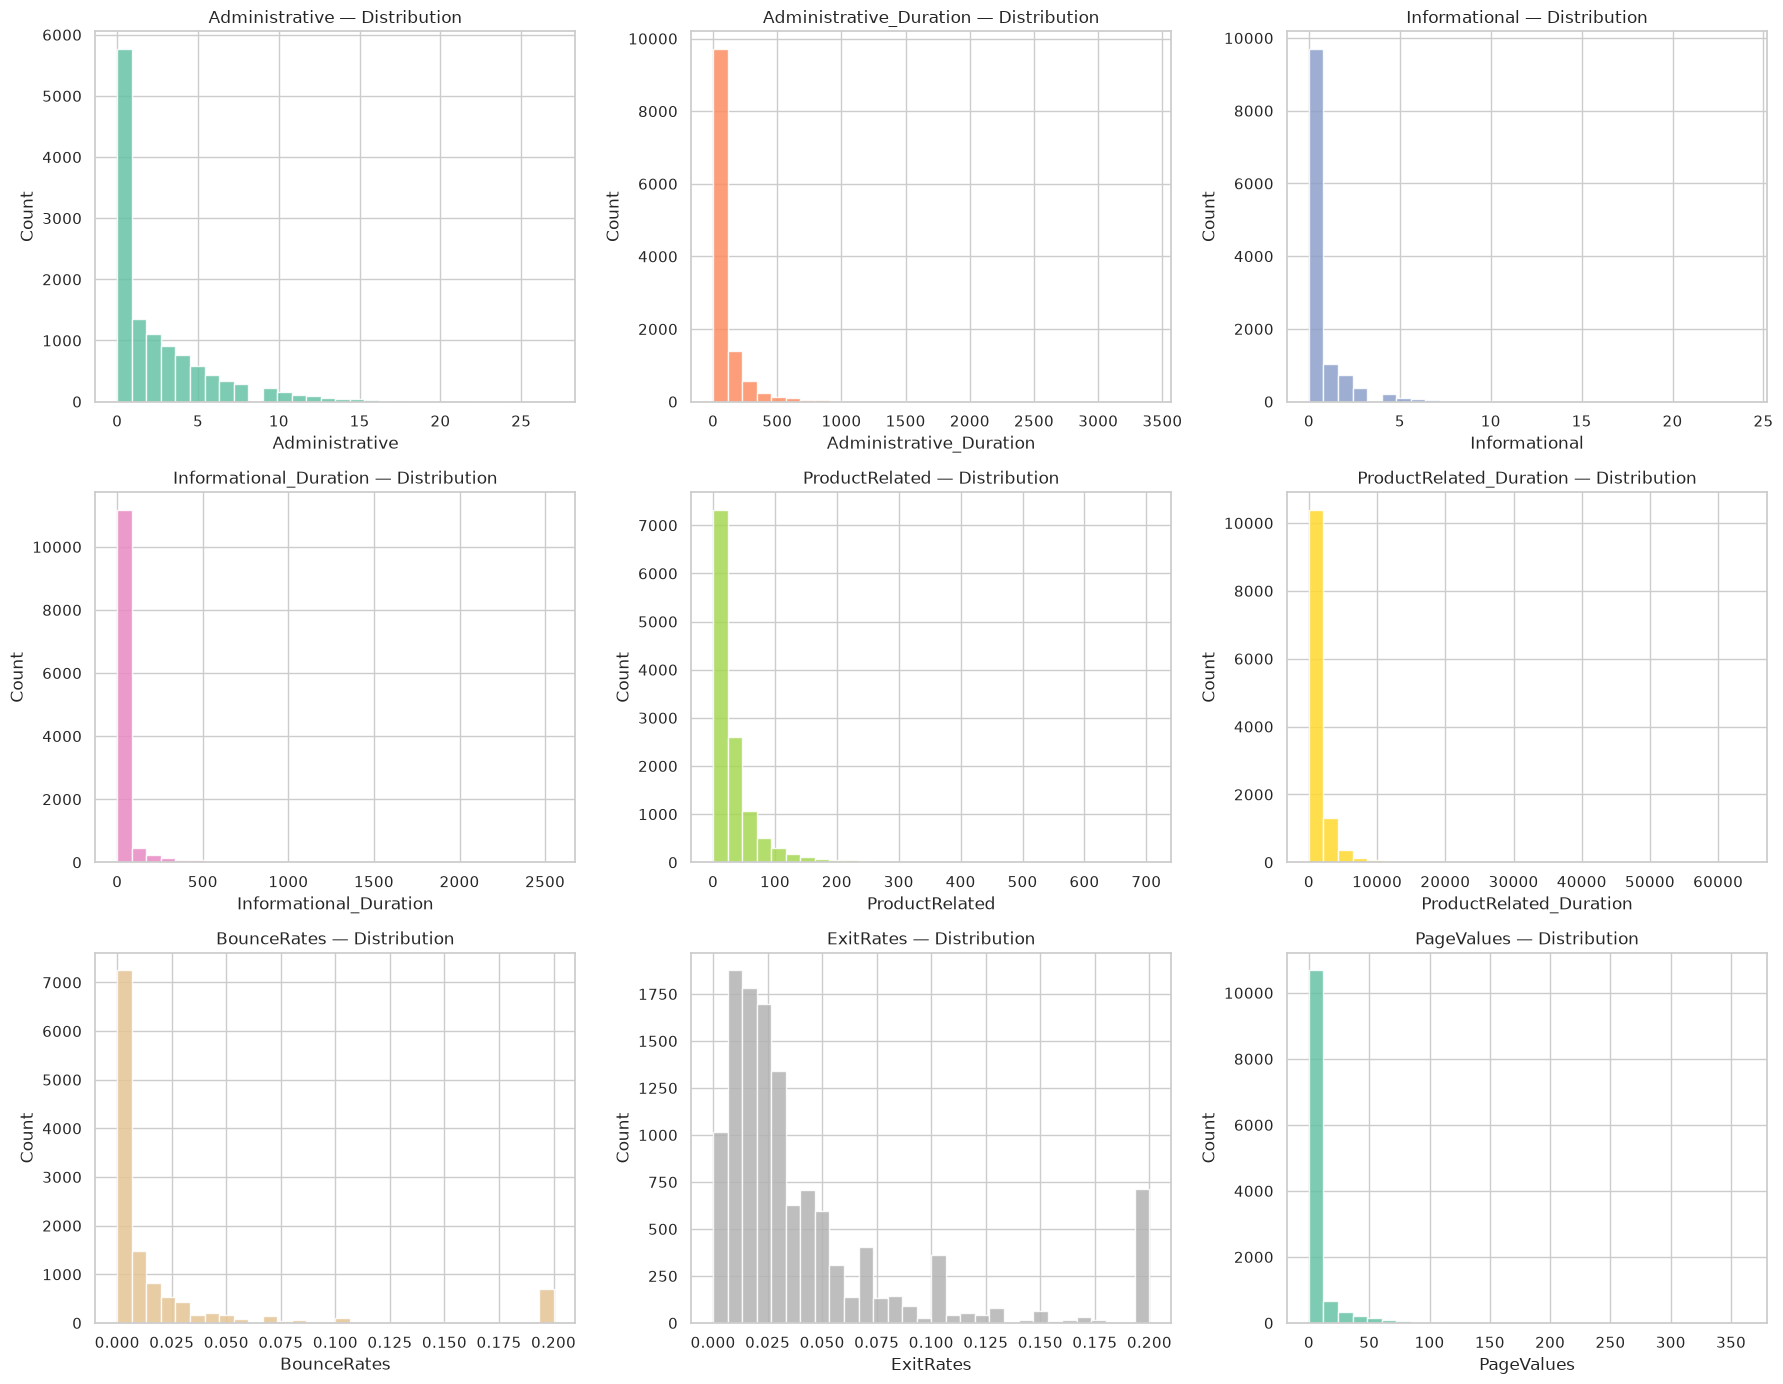

In [6]:
# Numerical feature distributions
num_cols = [
    "Administrative", "Administrative_Duration",
    "Informational", "Informational_Duration",
    "ProductRelated", "ProductRelated_Duration",
    "BounceRates", "ExitRates", "PageValues",
]

display(df[num_cols].describe())

# Boxplots — fliers hidden: the extreme outliers compress the boxes into a flat line
# (outliers are quantified separately in the Z-score cell below)
fig, axes = plt.subplots(3, 3, figsize=(18, 14))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    data = df[col].dropna()
    bp = axes[i].boxplot(
        data,
        patch_artist=True,
        showfliers=False,
        boxprops=dict(facecolor=sns.color_palette("Set2")[i % 8], alpha=0.8),
        medianprops=dict(color="black", linewidth=2),
    )
    axes[i].set_title(col)
    axes[i].set_ylabel("Value")
    axes[i].set_xticks([])

    x_right = bp["boxes"][0].get_path().vertices[:, 0].max()
    q1, median, q3 = data.quantile([0.25, 0.50, 0.75])

    points = [(median, True)]
    points += [(w.get_ydata()[1], False) for w in bp["whiskers"]]
    points += [(q1, False), (q3, False)]

    labels_done = set()
    for yval, bold in points:
        label = f"{yval:,.1f}" if abs(yval) >= 1 else f"{yval:.3f}"
        if label in labels_done:
            continue
        labels_done.add(label)
        axes[i].annotate(
            label,
            xy=(x_right, yval), xytext=(6, 0), textcoords="offset points",
            ha="left", va="center", fontsize=9,
            fontweight="bold" if bold else "normal",
        )

plt.tight_layout()
plt.show()

# Histograms
fig, axes = plt.subplots(3, 3, figsize=(18, 14))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    axes[i].hist(df[col].dropna(), bins=30, color=sns.color_palette("Set2")[i % 8], edgecolor="white", alpha=0.85)
    axes[i].set_title(f"{col} — Distribution")
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Count")

plt.tight_layout()
plt.show()

Outlier summary (|Z| > 3):


,outlier_count,outlier_pct,mean,std,z_threshold_lower,z_threshold_upper
Administrative,213,1.73,2.32,3.32,-7.65,12.28
Administrative_Duration,232,1.88,80.82,176.78,-449.52,611.16
Informational,260,2.11,0.50,1.27,-3.31,4.31
Informational_Duration,230,1.87,34.47,140.75,-387.78,456.72
ProductRelated,236,1.91,31.73,44.48,-101.70,165.16
ProductRelated_Duration,219,1.78,1194.75,1913.67,-4546.26,6935.75
BounceRates,708,5.74,0.02,0.05,-0.12,0.17
ExitRates,713,5.78,0.04,0.05,-0.10,0.19
PageValues,259,2.10,5.89,18.57,-49.82,61.59



Rows flagged as outlier in at least one column: 1869 (15.2%)


,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues
count,1869.000000,1869.000000,1869.000000,1869.000000,1869.000000,1869.000000,1869.000000,1869.000000,1869.000000
mean,4.061530,201.952439,1.445693,145.275554,58.197967,2338.426360,0.079455,0.088549,16.790908
std,5.339438,367.066912,2.418670,319.071042,89.039957,3932.701978,0.094353,0.088652,38.757181
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.001713,0.014286,0.000000
50%,1.000000,25.750000,0.000000,0.000000,20.000000,777.414615,0.009685,0.027928,0.000000
75%,7.000000,238.466667,2.000000,120.000000,76.000000,3065.945238,0.200000,0.200000,8.886649
max,27.000000,3398.750000,24.000000,2549.375000,705.000000,63973.522230,0.200000,0.200000,361.763742


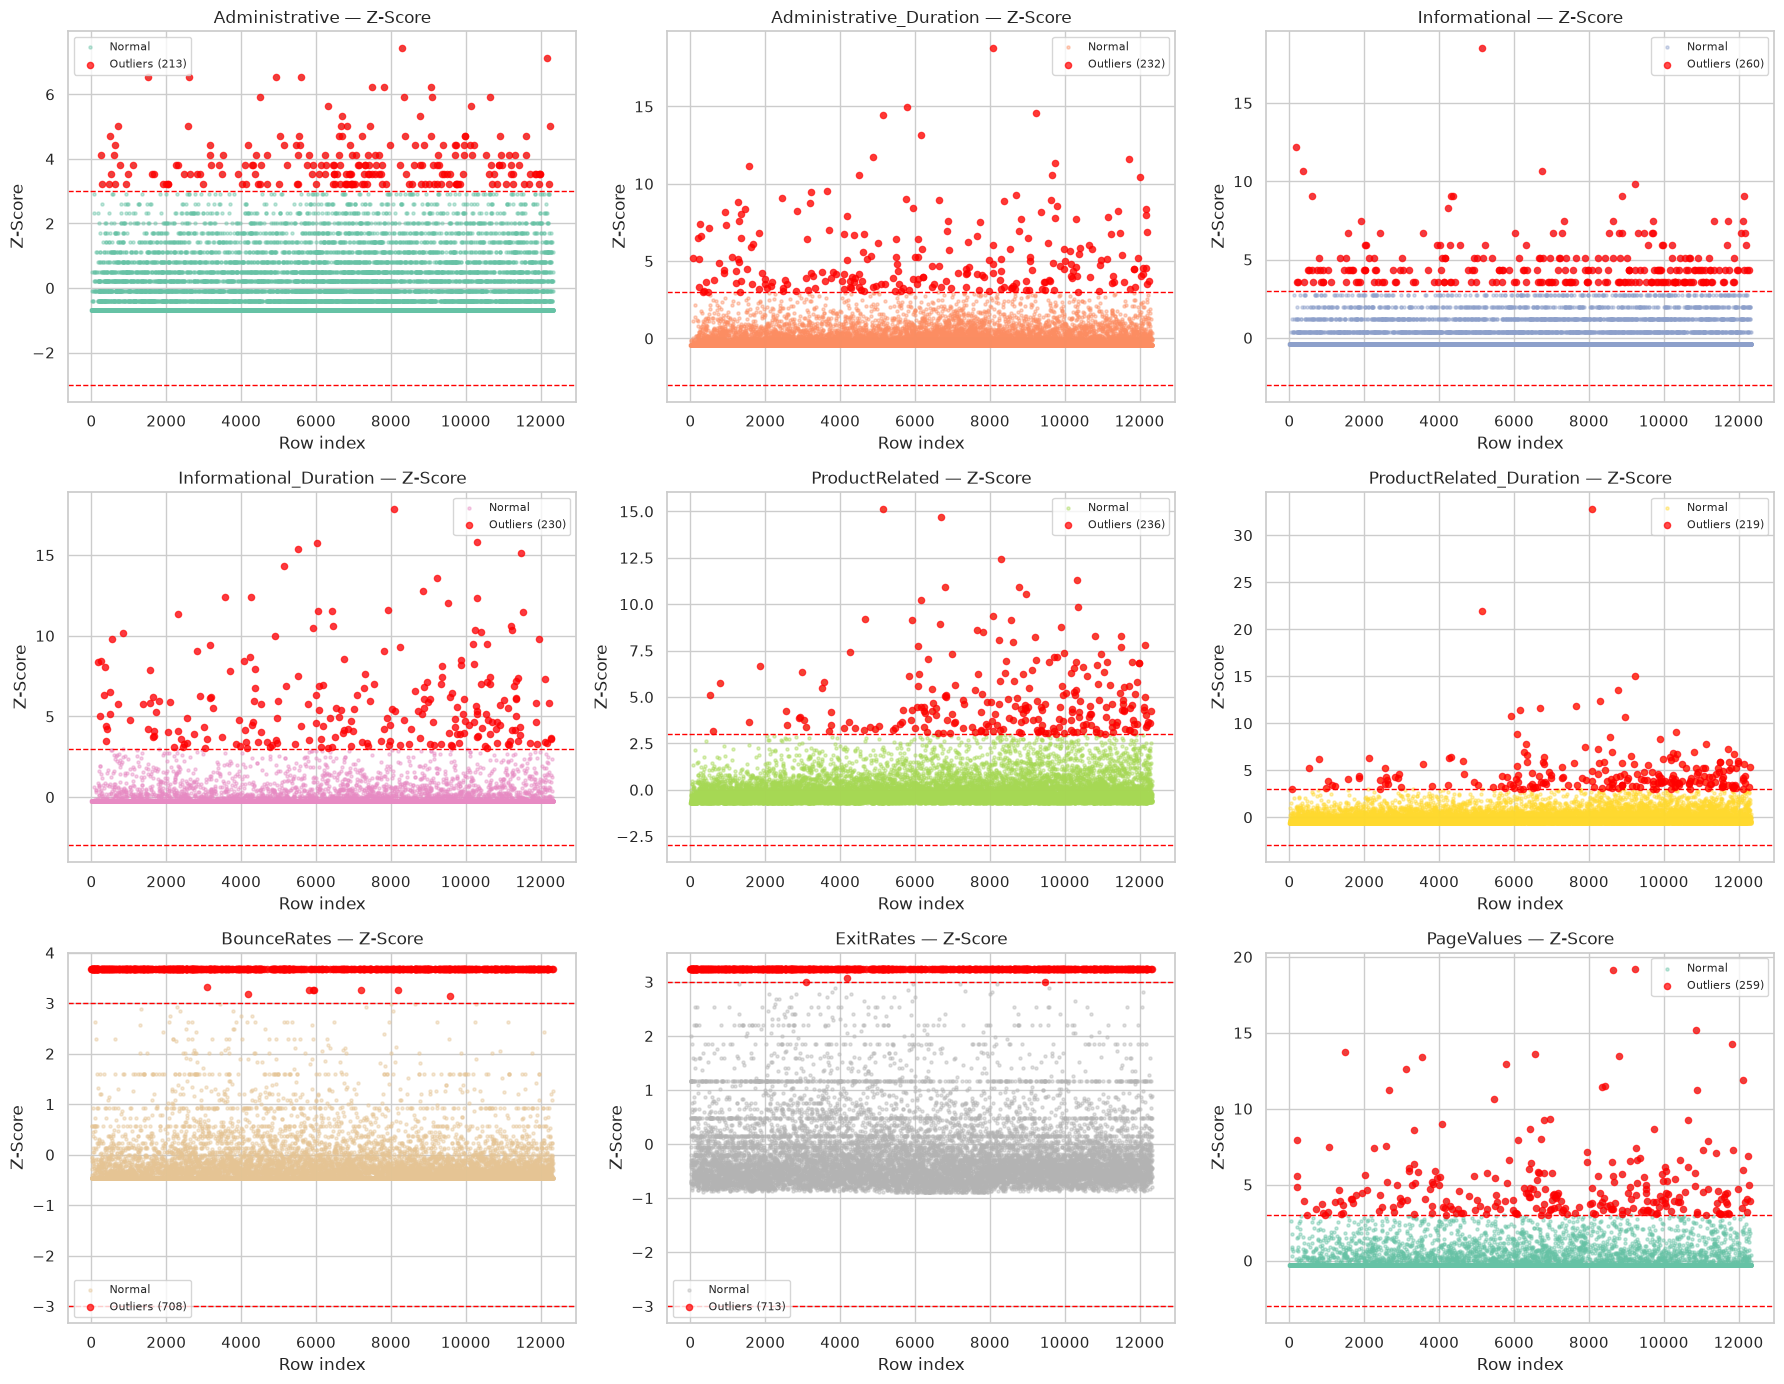

In [7]:
# Z-Score Outlier Detection (|Z| > 3)
num_df = df[num_cols]

z_scores = (num_df - num_df.mean()) / num_df.std()
outlier_mask = z_scores.abs() > 3

summary = pd.DataFrame({
    "outlier_count": outlier_mask.sum(),
    "outlier_pct": (outlier_mask.sum() / len(num_df) * 100).round(2),
    "mean": num_df.mean().round(2),
    "std": num_df.std().round(2),
    "z_threshold_lower": (num_df.mean() - 3 * num_df.std()).round(2),
    "z_threshold_upper": (num_df.mean() + 3 * num_df.std()).round(2),
})
print("Outlier summary (|Z| > 3):")
display(summary)

# Flag column on the full dataframe
outlier_flags = outlier_mask.any(axis=1)
print(f"\nRows flagged as outlier in at least one column: {outlier_flags.sum()} ({outlier_flags.mean():.1%})")
display(num_df[outlier_flags].describe())

# Visualise Z-scores per column
fig, axes = plt.subplots(3, 3, figsize=(18, 14))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    z = z_scores[col].dropna()
    color = sns.color_palette("Set2")[i % 8]
    axes[i].scatter(range(len(z)), z, s=5, alpha=0.4, color=color, label="Normal")
    outliers = z[z.abs() > 3]
    axes[i].scatter(outliers.index, outliers, s=20, color="red", alpha=0.7, label=f"Outliers ({len(outliers)})")
    axes[i].axhline(3,  color="red", linestyle="--", linewidth=1)
    axes[i].axhline(-3, color="red", linestyle="--", linewidth=1)
    axes[i].set_title(f"{col} — Z-Score")
    axes[i].set_ylabel("Z-Score")
    axes[i].set_xlabel("Row index")
    axes[i].legend(fontsize=8)

plt.tight_layout()
plt.show()

,Revenue,PageValues
count,12330,12330.000000
unique,2,NaN
top,False,NaN
freq,10422,NaN
mean,NaN,5.889258
std,NaN,18.568437
min,NaN,0.000000
25%,NaN,0.000000
50%,NaN,0.000000
75%,NaN,0.000000


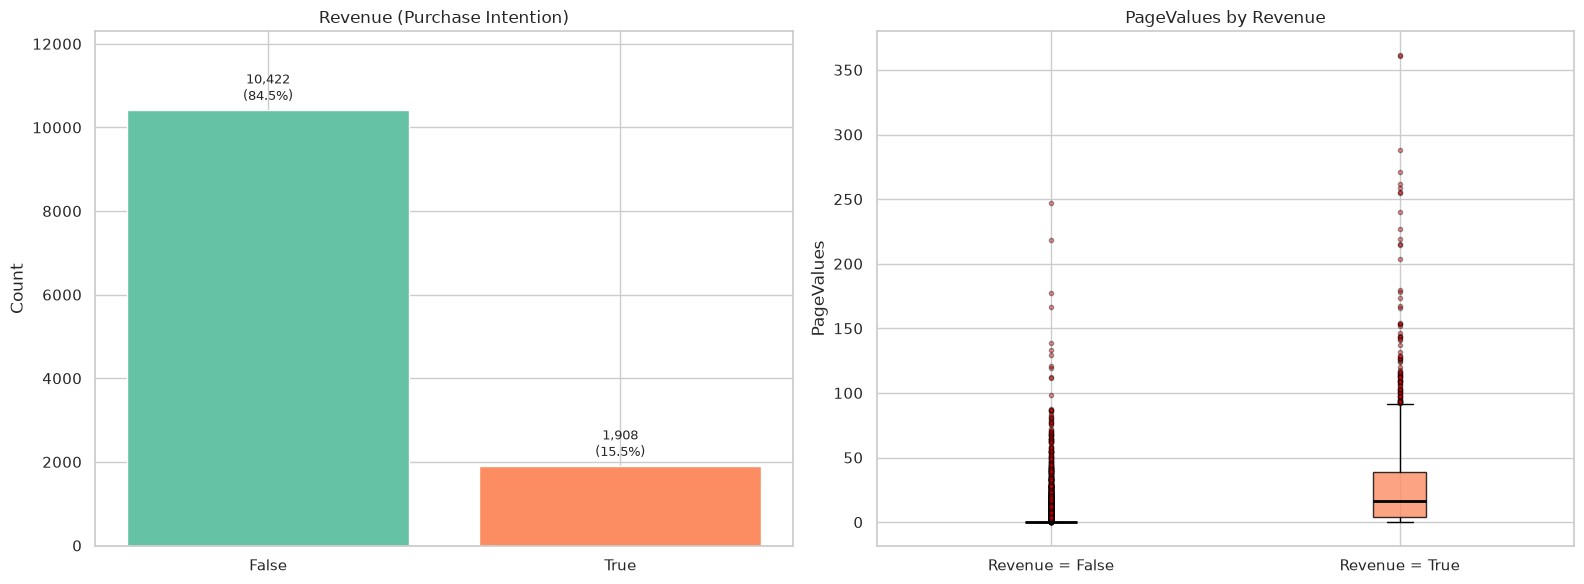

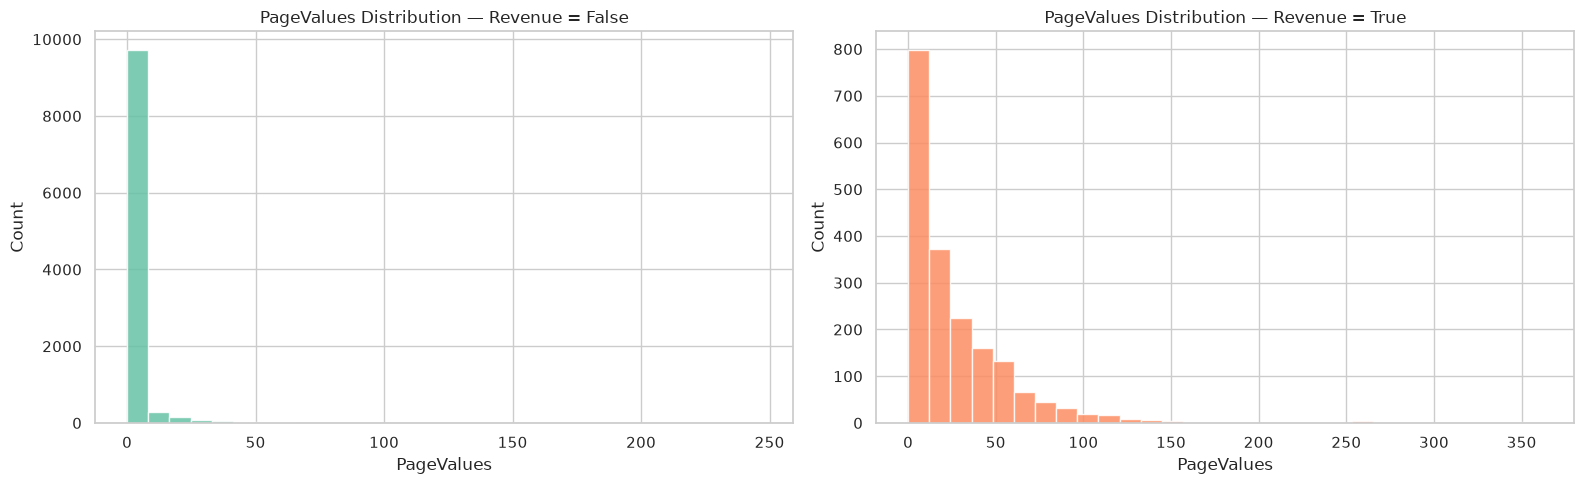

In [8]:
# Target — Revenue (purchase completed) and its strongest known signal, PageValues
display(df[["Revenue", "PageValues"]].describe(include="all"))

# Bar chart + PageValues boxplot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

counts = df["Revenue"].value_counts()
total = counts.sum()
bars = ax1.bar(counts.index.astype(str), counts.values, color=sns.color_palette("Set2", len(counts)))
ax1.set_title("Revenue (Purchase Intention)")
ax1.set_ylabel("Count")
ax1.set_ylim(0, counts.max() * 1.18)
for bar in bars:
    h = bar.get_height()
    ax1.annotate(
        f"{h:,}\n({h / total:.1%})",
        xy=(bar.get_x() + bar.get_width() / 2, h),
        xytext=(0, 4), textcoords="offset points",
        ha="center", va="bottom", fontsize=9,
    )

no_values  = df.loc[~df["Revenue"], "PageValues"]
yes_values = df.loc[df["Revenue"], "PageValues"]

palette = sns.color_palette("Set2", 2)
bp = ax2.boxplot(
    [no_values, yes_values],
    patch_artist=True,
    showfliers=True,
    boxprops=dict(alpha=0.8),
    medianprops=dict(color="black", linewidth=2),
    flierprops=dict(marker="o", markerfacecolor="red", markersize=3, alpha=0.4, linestyle="none"),
)
for patch, color in zip(bp["boxes"], palette):
    patch.set_facecolor(color)

ax2.set_title("PageValues by Revenue")
ax2.set_ylabel("PageValues")
ax2.set_xticks([1, 2])
ax2.set_xticklabels(["Revenue = False", "Revenue = True"])

plt.tight_layout()
plt.show()

# Histograms — PageValues split by Revenue
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for ax, (label, data), color in zip(axes, [("False", no_values), ("True", yes_values)], palette):
    ax.hist(data, bins=30, color=color, edgecolor="white", alpha=0.85)
    ax.set_title(f"PageValues Distribution — Revenue = {label}")
    ax.set_xlabel("PageValues")
    ax.set_ylabel("Count")

plt.tight_layout()
plt.show()